# Taller 6

## 1. Operadores de dilatación y erosión

### 1.1 Cree una nueva sección en su notebook.

### 1.2 Cargue y visualice la imagen morpho.png

### 1.3 Haga una umbralización de esta imagen, para obtener objetos negros sobre fondo blanco (umbral alrededor de 115).

In [156]:
# librerías
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from skimage.morphology import dilation, erosion, opening, closing
from skimage.morphology import footprint_rectangle, disk
from scipy.ndimage import morphological_gradient
from skimage.filters import sobel_h, sobel_v, sobel
from skimage.measure import label
from skimage import exposure
from scipy.ndimage import distance_transform_edt
from skimage.filters.rank import median

from skimage.morphology import skeletonize, thin
from skimage.segmentation import flood


In [2]:
# leer dierectorio de imagenes
images_path = 'images/'

os.listdir(images_path)

['AMOUR.png', 'MORPHO.png', 'SIC.png', 'OBJECTS.png', 'MEB.png']

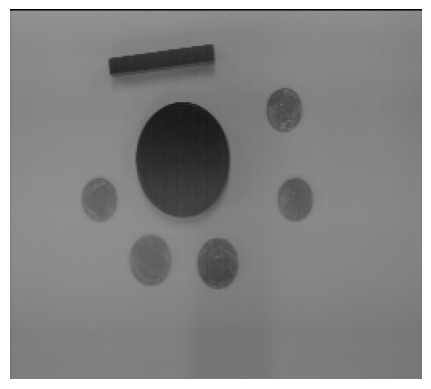

In [3]:
# leer la imagen morpho
morpho_image = cv2.imread(images_path+'MORPHO.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(morpho_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

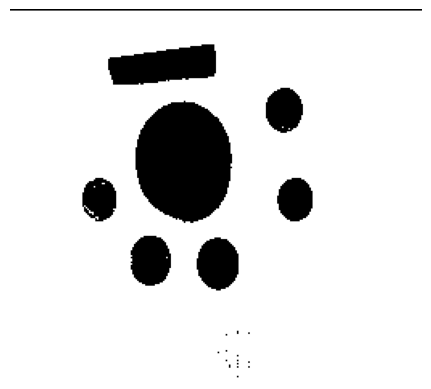

In [4]:
# umbralización
thres_value, morpho_umbralized = cv2.threshold(morpho_image, 115, 255, cv2.THRESH_BINARY)

# visualizar
plt.imshow(morpho_umbralized, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


### 1.4 Sobre la imagen binaria efectúe una dilatación con un elemento estructurante o máscara cuadrada de 29x29. ¿Qué obtiene como resultado?

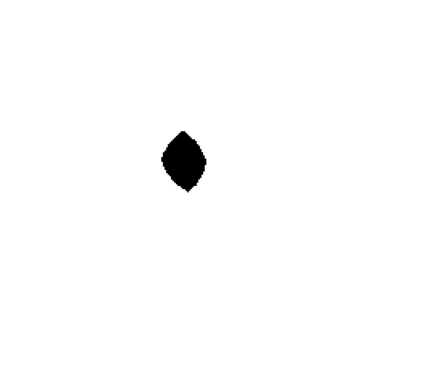

In [5]:
# dilatar con rectangulo de 29x29
structuring_element = np.ones((29, 29), dtype=np.uint8)
morpho_binary_dilated = dilation(morpho_umbralized, footprint=structuring_element)

# visualizar
plt.imshow(morpho_binary_dilated, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Al aplicar la dilatación con un elemento estructurante cuadrado de 29x29, los píxeles con valor 1 (que en este caso representan el fondo) se expanden sobre las regiones de valor 0. Dado que el tamaño de la máscara es grande, el fondo absorbe casi todas las áreas oscuras, eliminando todos los detalles negros excepto el de la moneda más grande, que resulta con una forma similar a la del elemento estructurante.

### 1.5 Sobre la imagen resultante, haga una erosión con la misma máscara. ¿Cómo es el objeto obtenido con respecto al original?

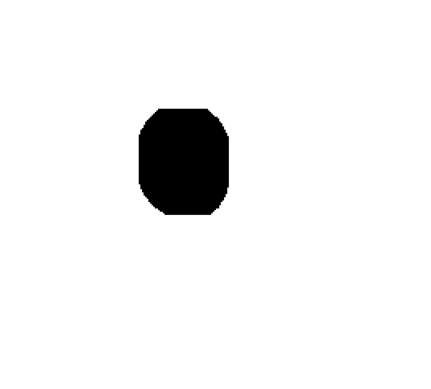

In [6]:
# erosionar con rectangulo de 29x29
morpho_binary_dilated_eroded = erosion(morpho_binary_dilated, footprint=structuring_element)

# visualizar
plt.imshow(morpho_binary_dilated_eroded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Al aplicar una erosión con el mismo elemento estructurante sobre la imagen obtenida en el punto 4, se obtiene una imagen donde los objetos blancos (el fondo) se reduce, y el objeto de color negro (0) se expande, recuperando el tamaño original del objeto correspondiente, pero con una forma cuadrada, debido al elemento estructurante.

### 1.6 Sobre la imagen resultado del punto anterior, haga una erosión con una máscara en cruz, de tamaño 11x11. Las máscaras en cruz deben crearse generando una matriz de nxn (tamaño deseado) y colocando 1’ s en la cruz. Los demás elementos se deben dejar vacíos (SIN CEROS).

In [7]:
cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (11, 11))
cross

array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]], dtype=uint8)

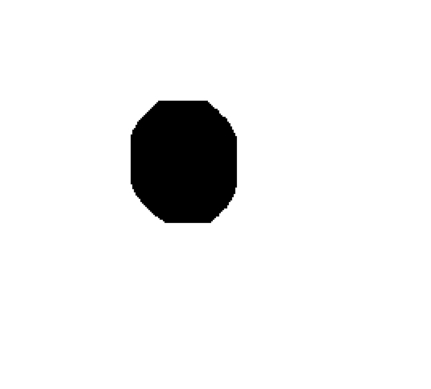

In [8]:
morpho_cross_eroded = erosion(morpho_binary_dilated_eroded, footprint=cross)

# visualizar
plt.imshow(morpho_cross_eroded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 1.7 Calcule el máximo entre esta última imagen y la imagen original umbralizada. ¿Cómo es el resultado obtenido?

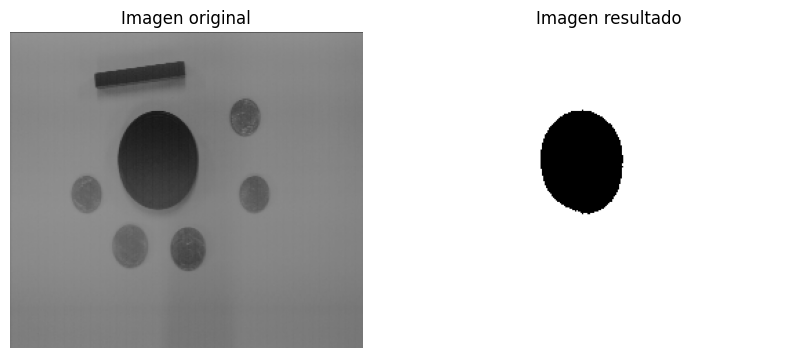

In [9]:
# maximo
max_img = np.maximum(morpho_cross_eroded, morpho_umbralized)

# visualizar
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(morpho_image, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(max_img, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen resultado')
plt.axis('off')
plt.show()

El resultado del máximo es un círculo muy similar en tamaño y forma al círculo original en la imagen.

### 1.8 Repita las operaciones 1 a 4, trabajando directamente con la imagen original no umbralizada (en niveles de gris).

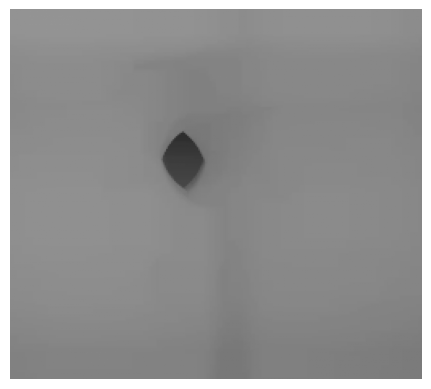

In [10]:
# dilatar con rectangulo de 29x29
structuring_element = footprint_rectangle(shape = (29, 29))
morpho_dilated = dilation(morpho_image, footprint=structuring_element)

# visualizar
plt.imshow(morpho_dilated, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

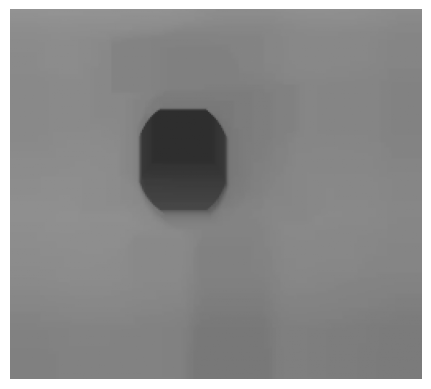

In [11]:
# erosionar con rectangulo de 29x29
morpho_dilated_eroded = erosion(morpho_dilated, footprint=structuring_element)

# visualizar
plt.imshow(morpho_dilated_eroded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

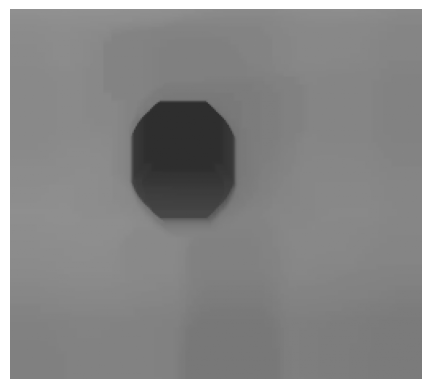

In [12]:
morpho_cross_eroded = erosion(morpho_dilated_eroded, footprint=cross)

# visualizar
plt.imshow(morpho_cross_eroded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

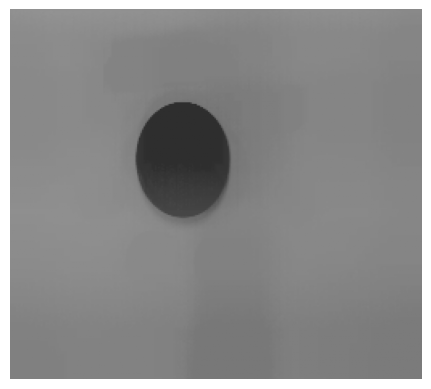

In [13]:
# maximo
max_img2 = np.maximum(morpho_cross_eroded, morpho_image)

# visualizar
plt.imshow(max_img2, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 1.9 ¿Cómo funcionan las operaciones de erosión y de dilatación en imágenes en niveles de gris?

Al aplicar erosión en imágenes en niveles de gris, se toma el valor mínimo de los píxeles bajo el elemento estructurante y se asigna al píxel central. Esto hace que las regiones más oscuras se expandan, mientras que las regiones más claras se reduzcan. Por otro lado, al aplicar dilatación, se toma el valor máximo de los píxeles bajo el elemento estructurante y se asigna al píxel central, lo que hace que las regiones más claras se expandan y las regiones más oscuras se reduzcan.

### 1.10 ¿Cómo es el resultado obtenido sobre la imagen en niveles de gris, comparado con el resultado sobre la imagen binaria?

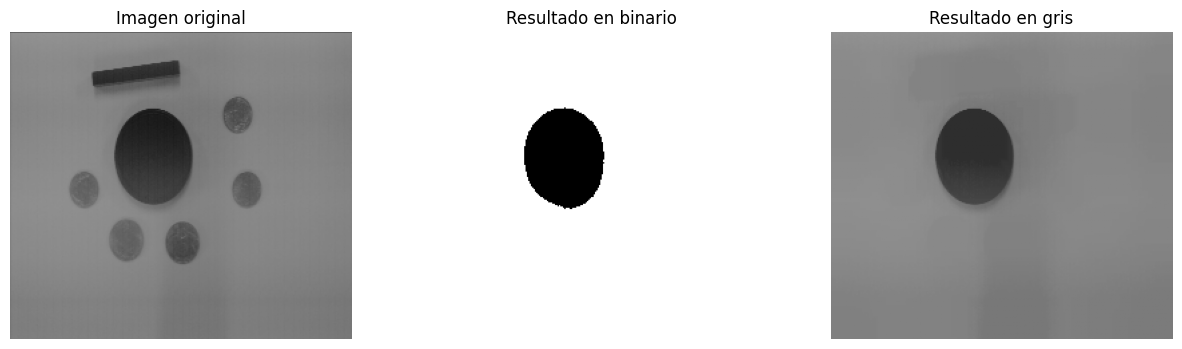

In [14]:
# visualizar imagen original, resultado en gris y en binario
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(morpho_image, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(max_img, cmap='gray', vmin=0, vmax=255)
plt.title('Resultado en binario')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(max_img2, cmap='gray', vmin=0, vmax=255)
plt.title('Resultado en gris')
plt.axis('off')
plt.show()

Observamos que el resultado sobre la imágen en niveles de gris es más suave y conserva de mejor manera los detalles del objeto que se buscaba seleccionar, variando en los tonos de gris, especialmente los más oscuros. El resultado sobre la imagen binaria tiene bordes más pixelados y una forma más cuadrada, debido a la naturaleza de la imagen binaria y al elemento estructurante utilizado.

## 2. Gradiente morfológico

### 2.1 Cree una nueva sección en su notebook.

### 2.2 Cargue y visualice la imagen meb.png.

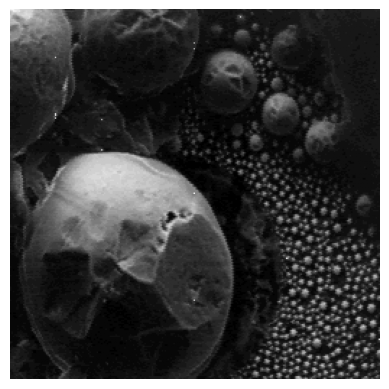

In [15]:
# cargar imagen meb
meb_image = cv2.imread(images_path+'meb.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(meb_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 2.3 Utilizando una máscara cuadrada de 3x3, calcule el gradiente morfológico de esta imagen.

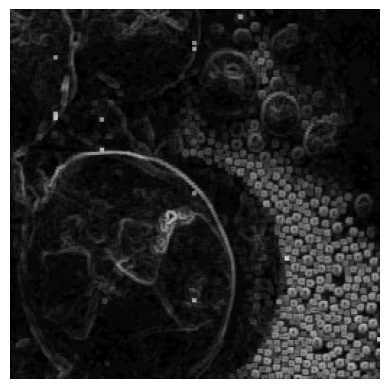

In [16]:
# mascara cuadrada de 3x3
structuring_element_3x3 = footprint_rectangle(shape = (3, 3))

# gradiente morfológico
mgimage = morphological_gradient(meb_image, footprint=structuring_element_3x3)

# visualizar
plt.imshow(mgimage, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 2.4 Genere la imagen de la norma del gradiente de la imagen meb.png con el operador de Sobel (ver Taller 3). Compare los resultados obtenidos (gradiente morfológico vs. norma del gradiente con Sobel). Puede efectuar una expansión del contraste sobre las dos imágenes obtenidas para visualizar mejor el resultado.

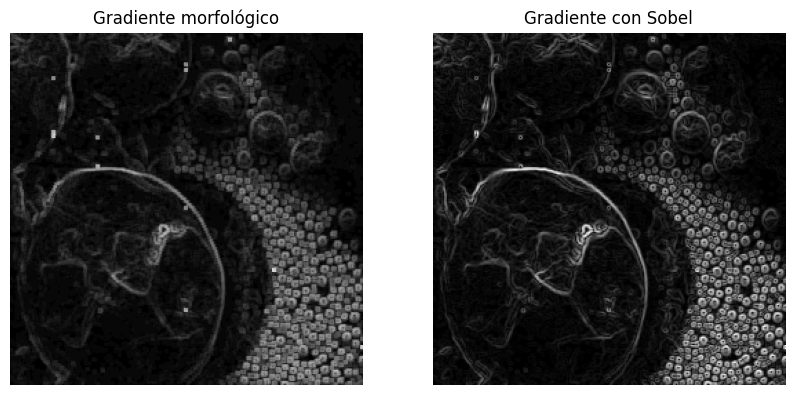

In [17]:
# norma del gradiente con Sobel
meb_sobel = sobel(meb_image)

# expandir contraste
meb_sobel_expanded = exposure.rescale_intensity(meb_sobel, in_range=(meb_sobel.min(),meb_sobel.max()), out_range=(0, 255))

# visualizar gradiente con sobel y con gradiente morfológico
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(mgimage, cmap='gray', vmin=0, vmax=255)
plt.title('Gradiente morfológico')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(meb_sobel_expanded, cmap='gray', vmin=0, vmax=255)
plt.title('Gradiente con Sobel')
plt.axis('off')
plt.show()

La principal diferencia entre el gradiente morfológico y la norma del gradiente con Sobel visualmente sobre la imagen MEB, es que el gradiente morfológico retorna los bordes con una forma muy similar a la del elemento estructurante utilizado, por lo que la imagen se ve más pixelada, con bordes más gruesos y con una forma más cuadrada. En cambio, la norma del gradiente con Sobel retorna bordes más suaves, con una forma más similar a la del objeto original y definidos. Los detalles pequeños se pierden mucho menos con Sobel.

### 2.5 Repita la operación 3 empleando la misma máscara, pero SIN utilizar el operador de gradiente morfológico (créelo con los operadores de dilatación y de erosión, precedidos por un filtrado mediano). ¿Cómo es el resultado obtenido?

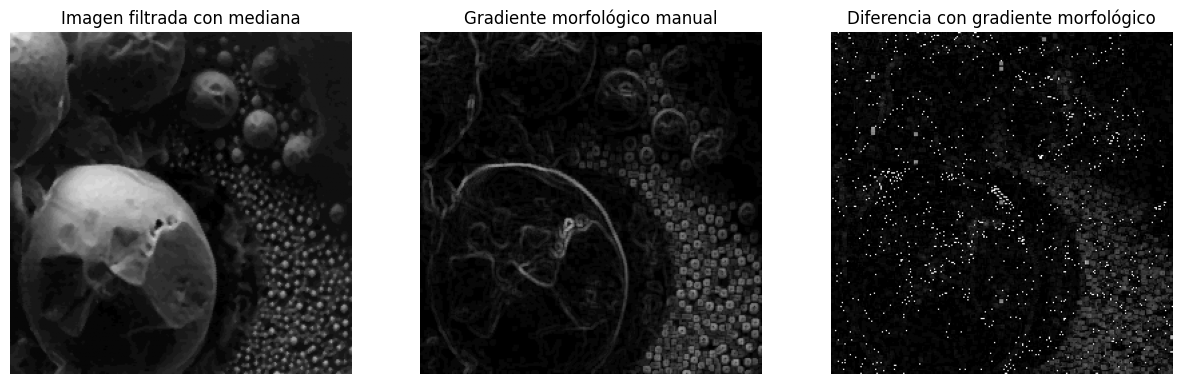

False


In [ ]:
# filtrado mediano a la imagen meb
filtered_meb = median(meb_image, footprint=structuring_element_3x3)

# calcular (A dilatar B) - (A erosionar B)
AdilatedB = dilation(filtered_meb, footprint=structuring_element_3x3)
AerosionB = erosion(filtered_meb, footprint=structuring_element_3x3)
morphological_gradient_manual = AdilatedB - AerosionB

# calcular diferencia entre el gradiente morfológico con función y manual
diff_gradient = mgimage - morphological_gradient_manual

# visualizar resultado del gradiente morfológico manual y diferencia con el gradiente morfológico con función
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(filtered_meb, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen filtrada con mediano')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(morphological_gradient_manual, cmap='gray', vmin=0, vmax=255)
plt.title('Gradiente morfológico manual')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(diff_gradient, cmap='gray', vmin=0, vmax=255)
plt.title('Diferencia con gradiente morfológico')
plt.axis('off')
plt.show()

print(np.all(mgimage == morphological_gradient_manual))

Al aplicar el gradiente morfológico sobre la imagen MEB previamente procesada con un filtro mediano, se obtiene una delimitación de contornos mucho más limpia y con menor pixelación. Al comparar el gradiente obtenido mediante la función directa frente al calculado manualmente (resta de ambos resultados), se observan ligeras discrepancias en los detalles de los bordes. Estas diferencias confirman que el filtrado mediano previo logró omitir irregularidades aisladas que el gradiente directo habría resaltado como ruido.

## 3. Operadores de apertura y cierre

### 3.1 Cree una nueva sección en su notebook.

### 3.2 Cargue y visualice la imagen amour.png.

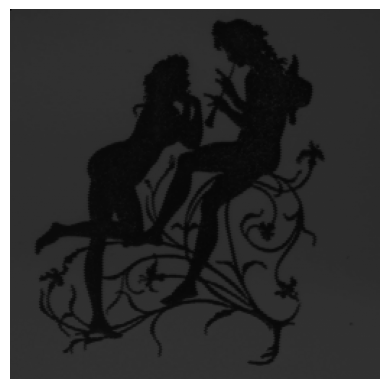

In [42]:
# imagen amour
amour_image = cv2.imread(images_path+'amour.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(amour_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.3 Realice la operación de apertura usando una máscara cuadrada de tamaño 5x5. ¿Qué partes fueron suprimidas? Nota: No es lo mismo aplicar dos veces seguidas la operación de apertura con una máscara de 3x3 que una sola vez con una máscara de 5x5. Hacer una segunda apertura no sirve de nada (no produce ningún efecto) ya que la operación de apertura es idempotente, es decir: apertura(apertura(imagen, máscara)) = apertura(imagen, máscara).

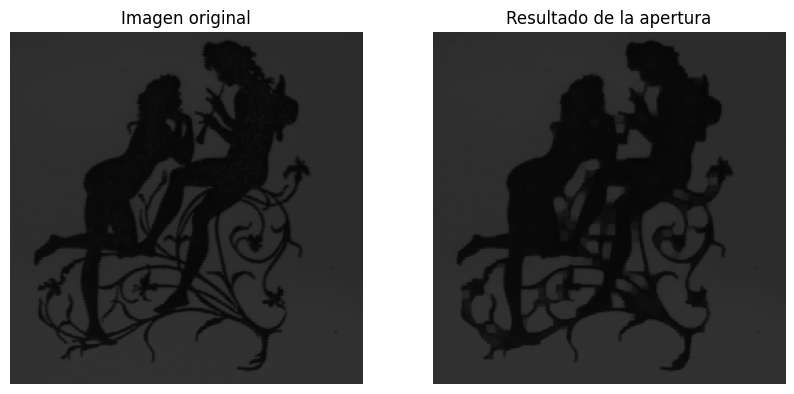

In [50]:
# crear la máscara
mask_square_5x5 = footprint_rectangle(shape=(5, 5))

# apertura
amour_open = opening(amour_image, footprint=mask_square_5x5)

# visualizar imagen original y resultado de la apertura
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(amour_image, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(amour_open, cmap='gray', vmin=0, vmax=255)
plt.title('Resultado de la apertura')
plt.axis('off')
plt.show()

Al realizar la apertura sobre la imagen, se eliminan huecos y entradas pequeñas de las flores, lo que permite resaltar las estructuras principales de la imagen.

### 3.4 Retome la imagen original, y aplique una umbralización para binarizarla (umbral = 35).

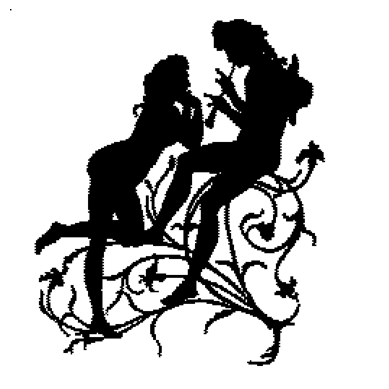

In [44]:
# umbralizacion de la imagen original
thres_value, amour_thresholded = cv2.threshold(amour_image, 35, 255, cv2.THRESH_BINARY)

# visualizar
plt.imshow(amour_thresholded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.5 Realice el cierre de la imagen. Para esto, efectúe 4 cierres aplicando sucesivamente las 4 máscaras lineales simétricas de tamaño 1x3 (en este orden: las dos diagonales ( / y después \ ), horizontal ( - ) y vertical ( | )). 

- Las máscaras diagonales (u oblicuas) deben crearse generando una matriz de 3x3 y colocando 1’ s sobre las diagonales. Los demás elementos se deben dejar vacíos (SIN CEROS).

- La máscara horizontal debe crearse generando una matriz de 3x1 llena de 1’s.

- La máscara vertical debe crearse generando una matriz de 1x3 llena de 1’s.

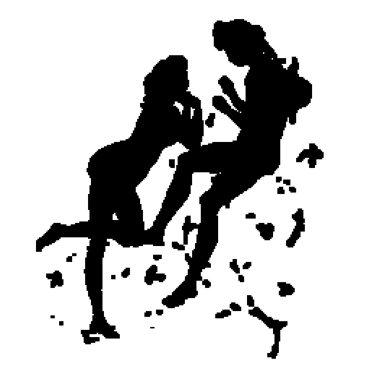

In [45]:
# diagonales
diag_principal = np.zeros((3, 3), dtype=np.uint8)
diag_principal[0, 0] = 1
diag_principal[1, 1] = 1
diag_principal[2, 2] = 1

diag_secundaria = np.zeros((3, 3), dtype=np.uint8)
diag_secundaria[0, 2] = 1
diag_secundaria[1, 1] = 1
diag_secundaria[2, 0] = 1

# horizontal
horizontal = np.ones((3, 1), dtype=np.uint8)

# vertical
vertical = np.ones((1, 3), dtype=np.uint8)

# realce:
# 1. diagonal secundaria
amour_closed_diag_sec = closing(amour_thresholded, footprint=diag_secundaria)
# 2. diagonal principal
amour_closed_diag_prin = closing(amour_closed_diag_sec, footprint=diag_principal)
# 3. horizontal
amour_closed_horizontal = closing(amour_closed_diag_prin, footprint=horizontal)
# 4. vertical
amour_closed_vertical = closing(amour_closed_horizontal, footprint=vertical)

# visualizar
plt.imshow(amour_closed_vertical, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.6 ¿Cuál es el efecto obtenido?

Al aplicar el cierre sobre una imagen donde los objetos son negros y el fondo es blanco, el efecto sobre las estructuras oscuras es equivalente a una apertura. Esto ocurre porque el cierre busca rellenar huecos en el valor 1 (fondo), lo que en la práctica se traduce en la eliminación de los elementos negros que sean más pequeños que el elemento estructurante. En este caso, las ramas de las flores y la flauta desaparecen debido a que su grosor es inferior a los 3 píxeles de las máscaras lineales. Al emplear sucesivamente los elementos estructurantes en las cuatro orientaciones (diagonales, horizontal y vertical), se garantiza que cualquier estructura delgada sea suprimida independientemente de su dirección

### 3.7 Tome el negativo de la imagen resultado, de tal manera que las figuras se vuelven blancas.

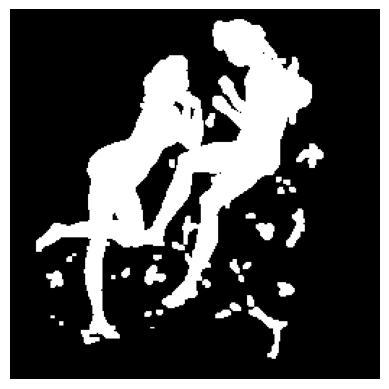

In [46]:
# negativo del resultado
neg_amour_realce = 255 - amour_closed_vertical

# visualizar
plt.imshow(neg_amour_realce, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.8 Seleccione el componente conexo más grande. ¿Cuál es el resultado?

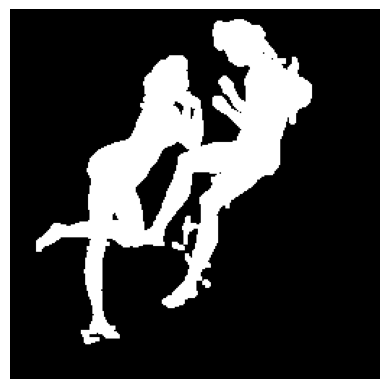

In [49]:
# componentes conexas
connected_components = label(neg_amour_realce, background=0, connectivity=2)

# tomar el más grande (distinto al fondo 0, el que mayor etiquetas tenga)
counts = np.bincount(connected_components.ravel()) # retorna un vector con el conteo de cada etiqueta
counts[0] = 0 # dejamos el fondo como 0 para no considerarlo
largest_label = counts.argmax() # tomamos el índice del conteo máximo, que corresponde a la etiqueta del componente conexo más grande

connected_components[connected_components != largest_label] = 0
connected_components[connected_components == largest_label] = 255

# visualizar
plt.imshow(connected_components, cmap='gray')
plt.axis('off')
plt.show()

El componente conexo más grande se obtiene haciendo un conteo de etiquetas e ignorando la correspondiente al fondo. Como resultado, se obtienen las figuras correspondientes a los personajes de la imagen, con algunos detalles de las flores en los pies.

## 4. Etiquetado de objetos

### 4.1 Cree una nueva sección en su notebook.
### 4.2 Cargue y visualice la imagen sic.png.

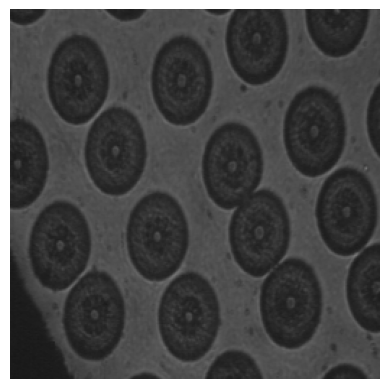

In [51]:
# cargar imagen sic
sic_image = cv2.imread(images_path+'sic.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(sic_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 4.3 Umbralice esta imagen de forma tal que las células del fondo sean separadas (umbral entre 55 y 70), y calcule su negativo.

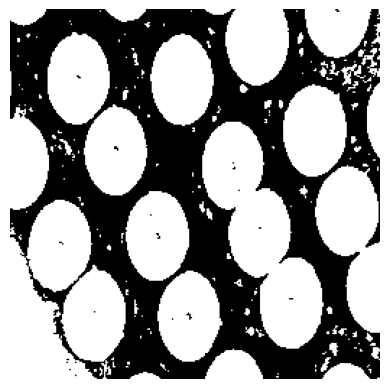

In [52]:
# umbralizar
thres_value, sic_thresholded = cv2.threshold(sic_image, 70, 255, cv2.THRESH_BINARY_INV)

# visualizar
plt.imshow(sic_thresholded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 4.4 Con una máscara en cruz de 3x3, haga dilataciones para rellenar los huecos al interior de las células.

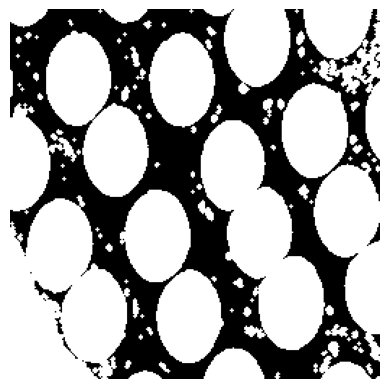

In [53]:
# crear máscara en cruz de 3x3
cross = np.zeros((3, 3), dtype=np.uint8)
cross[1, :] = 1
cross[:, 1] = 1

# dilatar con mascara en cruz
sic_dilated = dilation(sic_thresholded, footprint=cross)

# visualizar
plt.imshow(sic_dilated, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 4.5 Cambie de máscaras: se utilizarán ahora máscaras lineales (oblicuas). Utilice las mismas máscaras oblicuas creadas en el punto de apertura y cierre de este taller. Con el operador de erosión, separe las diferentes células. Ayuda: Para separar las células es necesario erosionar por lo menos 10 veces con una máscara lineal oblicua (/) y 6 veces con una máscara ortogonal a la primera (\\).

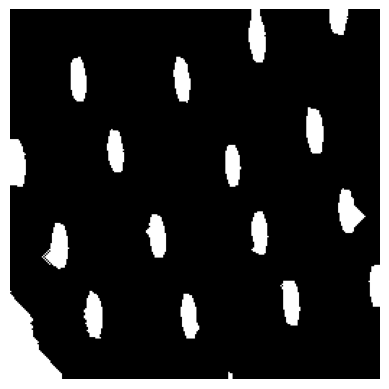

In [64]:
# diagonales
diag_principal = np.zeros((3, 3), dtype=np.uint8)
diag_principal[0, 0] = 1
diag_principal[1, 1] = 1
diag_principal[2, 2] = 1

diag_secundaria = np.zeros((3, 3), dtype=np.uint8)
diag_secundaria[0, 2] = 1
diag_secundaria[1, 1] = 1
diag_secundaria[2, 0] = 1

# erosionar 10 veces con la máscara lineal oblicua (/)
sic_eroded_diag_sec = sic_dilated.copy()
for _ in range(10):
    sic_eroded_diag_sec = erosion(sic_eroded_diag_sec, footprint=diag_secundaria)

# erosionar 6 veces con la máscara ortogonal a la primera (\)
sic_eroded_diag_prin = sic_eroded_diag_sec.copy()
for _ in range(7):
    sic_eroded_diag_prin = erosion(sic_eroded_diag_prin, footprint=diag_principal)

sic_final = sic_eroded_diag_prin

# visualizar
plt.imshow(sic_final, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 4.6 Etiquete la imagen y visualice el resultado. Determine cuántas células enteras fueron detectadas ¿Qué ocurre con el borde?

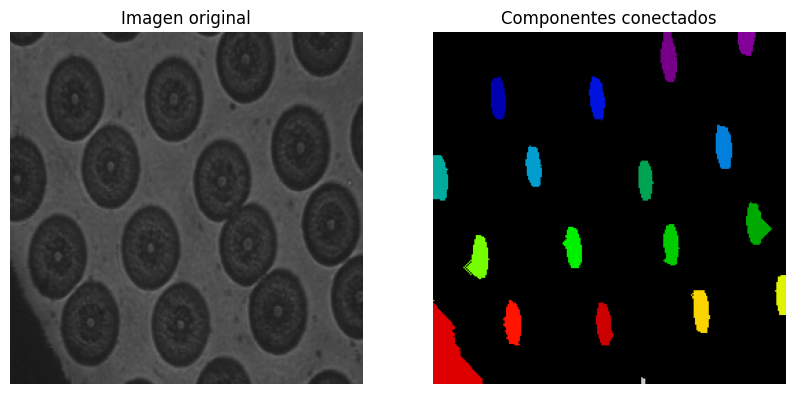

In [65]:
# etiquetar
connected_components = label(sic_final, background=0, connectivity=2)

# visualizar imagen original y resultado de la etiquetación
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sic_image, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(connected_components, cmap='nipy_spectral')
plt.title('Componentes conectados')
plt.axis('off')
plt.show()

Se logran identificar 17 componentes conexos distintos al fondo. Debido a que el borde de la imagen posee niveles de gris similares a los de las células, el umbral seleccionado no logra una segmentación perfecta, provocando que el borde sea indexado como un objeto adicional. Esto sesga el conteo de células enteras y genera artefactos o picos en los límites de la imagen como consecuencia de las operaciones de erosión. Por lo tanto, el resultado refleja tanto las células detectadas como restos de la estructura del borde que no pudieron ser aislados.

Es importante destacar también que en la imagen original se pueden observar células que están cortadas por el borde, dificultando su identificación, pues la erosión aplicada para separar las células las elimina completamente.

## 5. Imagen de distancia

### 5.1 Cree una nueva sección en su notebook.
### 5.2 Cargue y visualice la imagen objects.png.

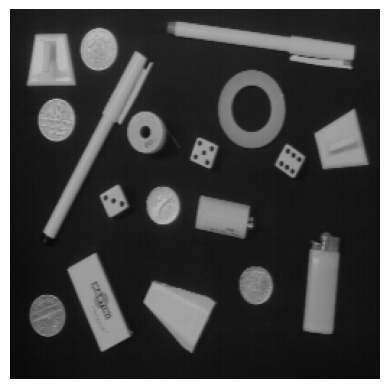

In [76]:
# cargar imagen objects
objects_image = cv2.imread(images_path+'objects.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(objects_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 5.3 Umbralice esta imagen para separar los objetos del fondo (umbral=70).

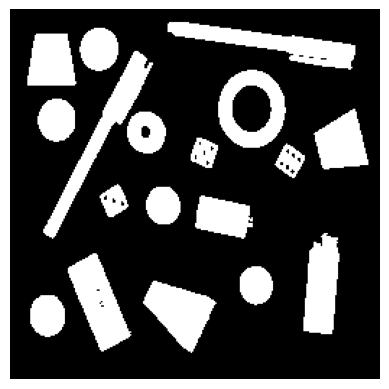

In [77]:
# umbralizar
thresh_value, objects_thresholded = cv2.threshold(objects_image, 70, 255, cv2.THRESH_BINARY)

# visualizar
plt.imshow(objects_thresholded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 5.4 Calcule la imagen de distancia. Puede efectuar una expansión del contraste sobre la imagen de distancia para visualizar mejor el resultado. Ajuste el Window/Level.

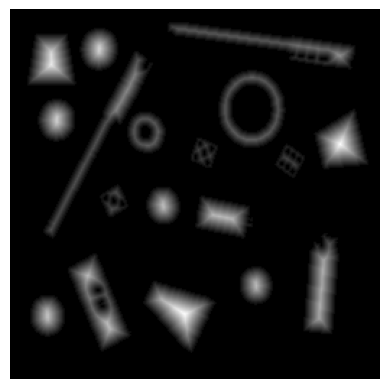

In [78]:
# calcular imagen de distancia
edm = distance_transform_edt(objects_thresholded)

# expansión de contraste
edm = exposure.rescale_intensity(edm, in_range=(edm.min(), edm.max()), out_range=(0, 255)).astype(np.uint8)

# visualizar
plt.imshow(edm, cmap='gray')
plt.axis('off')
plt.show()


### 5.5 Calcule ahora el negativo de la imagen umbralizada del punto 3. Ahora realice el cálculo de la distancia euclidiana. Utilizando la imagen resultante, determine la distancia mínima entre los dos lápices. Utilice máscaras y operaciones sobre pixeles para determinar el valor del pixel en el mapa de distancias a medio camino entre la distancia mínima de los dos lápices.

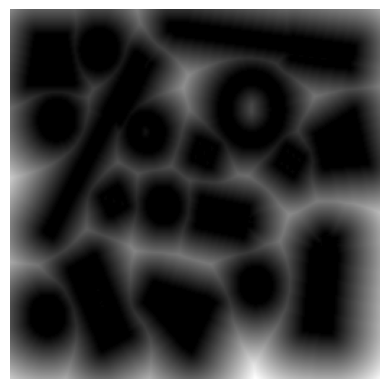

In [79]:
# negativo de umbral
objects_thresholded_neg = 255 - objects_thresholded

# distancia
distance_map = distance_transform_edt(objects_thresholded_neg)

# visualizar
plt.imshow(distance_map, cmap='gray')
plt.axis('off')
plt.show()

Para determinar la distancia mínima entre los dos lápices se aplicaran los siguientes procedimientos:
- Seleccionar sobre la imagen umbralizada dos componentes correspondientes a cada lápiz (las etiquetas de más elementos sin contar el fondo).
- Calcular la imagen de distancias sobre el negativo del paso anterior, de tal manera que los píxeles correspondientes a cada lápiz tengan un valor de distancia igual a cero, y el resto de la imagen tenga valores de distancia crecientes a medida que se alejan de los lápices.
- Identificar una región de interés (ROI) que contenga el resultado entre los dos lápices.
- Dentro de esta ROI, encontrar el píxel con el valor máximo, que corresponderá a la distancia mínima entre los dos lápices.

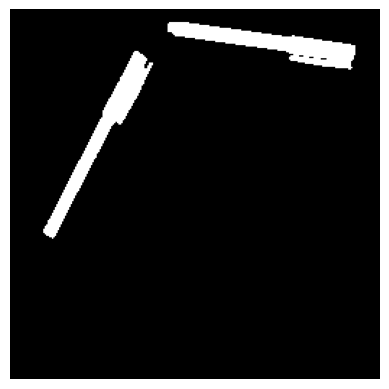

In [82]:
# paso 1: componentes conexas
connected_components = label(objects_thresholded, background=0, connectivity=2)

# tomar las dos componentes más grandes (distinto al fondo 0)
counts = np.bincount(connected_components.ravel()) # retorna un vector con el conteo de cada etiqueta
counts[0] = 0 # dejamos el fondo como 0 para no considerarlo
largest_labels = counts.argsort()[-2:] # tomamos los índices de las dos etiquetas con mayor conteo, que corresponden a las componentes conexas más grandes

# visualizar las dos componentes más grandes
largest_components = np.zeros_like(connected_components)
for lab in largest_labels:
    largest_components[connected_components == lab] = 255

plt.imshow(largest_components, cmap='gray')
plt.axis('off')
plt.show()

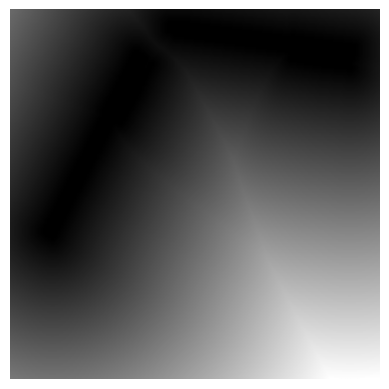

In [83]:
# paso 2: imagen de distancias sobre el negativo del paso anterior
largest_components_neg = 255 - largest_components
distance_map_largest = distance_transform_edt(largest_components_neg)

# visualizar
plt.imshow(distance_map_largest, cmap='gray')
plt.axis('off')
plt.show()

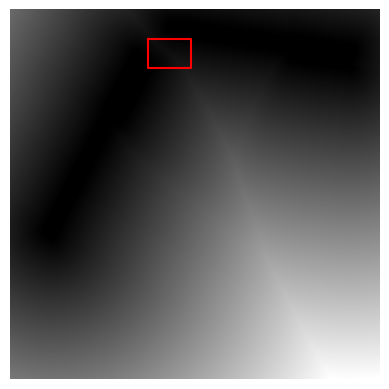

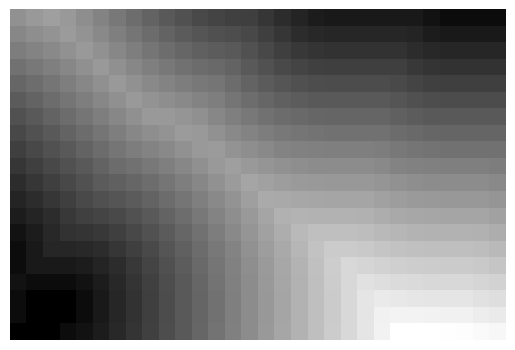

In [108]:
# paso 3: identificar una región de interés (ROI) que contenga el resultado entre los dos lápices
filas_extremos_roi = [20, 40]
columnas_extremos_roi = [95, 125]

# colocar un cuadrado delimitador rojo sobre la imagen de distancias con la ROI
plt.imshow(distance_map_largest, cmap='gray')
plt.plot([columnas_extremos_roi[0], columnas_extremos_roi[1], columnas_extremos_roi[1], columnas_extremos_roi[0], columnas_extremos_roi[0]],
         [filas_extremos_roi[0], filas_extremos_roi[0], filas_extremos_roi[1], filas_extremos_roi[1], filas_extremos_roi[0]], color='red')
plt.axis('off')
plt.show()

# visualizar la ROI
roi = distance_map_largest[filas_extremos_roi[0]:filas_extremos_roi[1], columnas_extremos_roi[0]:columnas_extremos_roi[1]]
plt.imshow(roi, cmap='gray')
plt.axis('off')
plt.show()

In [109]:
# paso 4: dentro de esta ROI, encontrar el píxel con el valor máximo
v_max = np.max(roi)
print(f"El valor máximo en el mapa es: {v_max}")

El valor máximo en el mapa es: 20.09975124224178


## 6. Esqueleto y adelgazamiento de una imagen

### 6.1 Cree una nueva sección en su notebook.

### 6.2 Cargue y visualice la imagen rect.png.

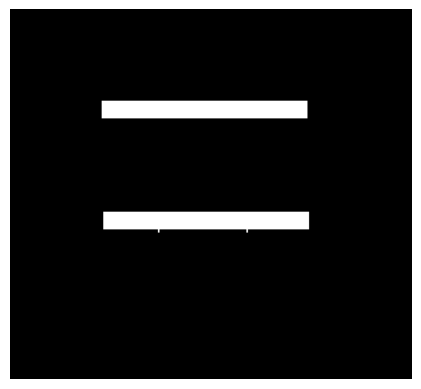

In [110]:
# cargar imagen rect
rect_image = cv2.imread(images_path+'RECT.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(rect_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 6.3 Efectúe la esqueletización de esta imagen. Pruebe cambiando el parámetro opcional method a 'zhang' y luego a 'lee'. Compare los resultados. Explique cómo funcionan ambos algoritmos en términos generales.

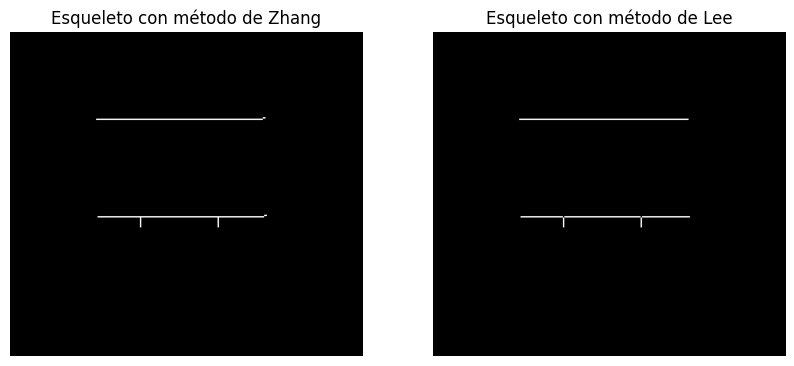

In [116]:
sk_zhang = skeletonize(rect_image, method='zhang')
sk_lee = skeletonize(rect_image, method='lee')

# visualizar esqueletos obtenidos con ambos métodos
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sk_zhang, cmap='gray')
plt.title('Esqueleto con método de Zhang')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(sk_lee, cmap='gray')
plt.title('Esqueleto con método de Lee')
plt.axis('off')
plt.show()

El algoritmo de Zhang-Suen es un proceso paralelo que elimina píxeles de borde mediante una máscara de $3 \times 3$. El método evalúa la conectividad de los 8 vecinos y, apoyado en una tabla de consulta (LUT), suprime selectivamente los píxeles en cada iteración hasta obtener un esqueleto que preserva la topología original.

Por su parte, el algoritmo de Lee utiliza un enfoque de vecindad de $3 \times 3 \times 3$. Aunque su diseño es nativo para 3D, en imágenes bidimensionales identifica y elimina candidatos de forma secuencial. El proceso itera hasta alcanzar la convergencia, asegurando que no se fracture la estructura del objeto durante la reducción.

Al comparar los resultados, Zhang-Suen genera un esqueleto funcional pero con ligeras distorsiones en los extremos. En cambio, Lee ofrece una mayor fidelidad morfológica y uniformidad en los bordes.

### 6.4 Efectúe un adelgazamiento de la imagen original. Puede efectuar una calibración del histograma de la imagen obtenida para visualizar mejor el resultado. Compare el resultado con los de la esqueletización.

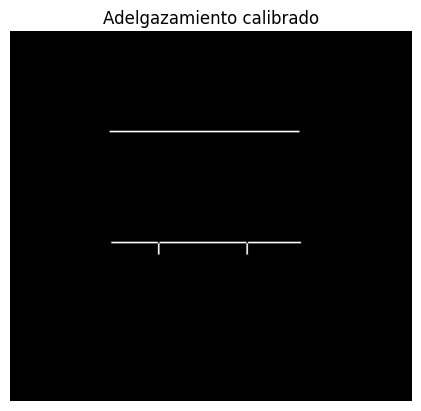

False


In [118]:
# adelgazamiento
thin_image = thin(rect_image)

# calibración del histograma
thin_image_calibrated = exposure.rescale_intensity(thin_image, in_range=(thin_image.min(), thin_image.max()), out_range=(0, 255)).astype(np.uint8)

# visualizar adelgazamiento calibrado y diferencia con Lee
plt.imshow(thin_image_calibrated, cmap='gray', vmin=0, vmax=255)
plt.title('Adelgazamiento calibrado')
plt.axis('off')
plt.show()

# verificar si el adelgazamiento es igual a la esqueletización con Lee
print(np.array_equal(thin_image, sk_lee))

El algoritmo de adelgazamiento tiene resultados muy parecidos a los de la esqueletización con el método de Lee, aunque con un esqueleto un poco más grueso. Se comprueba además que no sean idénticos.

### 6.5 Cargue y visualice la imagen angio.png.

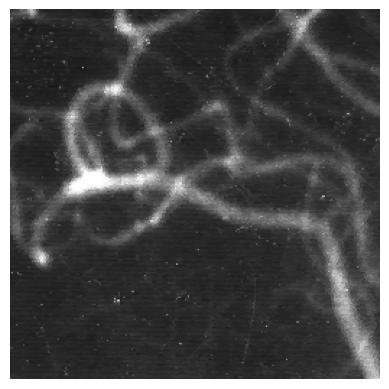

In [126]:
# cargar imagen angio
angio_image = cv2.imread(images_path+'ANGIO.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(angio_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 6.7 Umbralice la imagen utilizando el algoritmo de OTSU, después fíltrela efectuando un cierre y una apertura de la imagen, con una máscara en cruz de 3x3.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

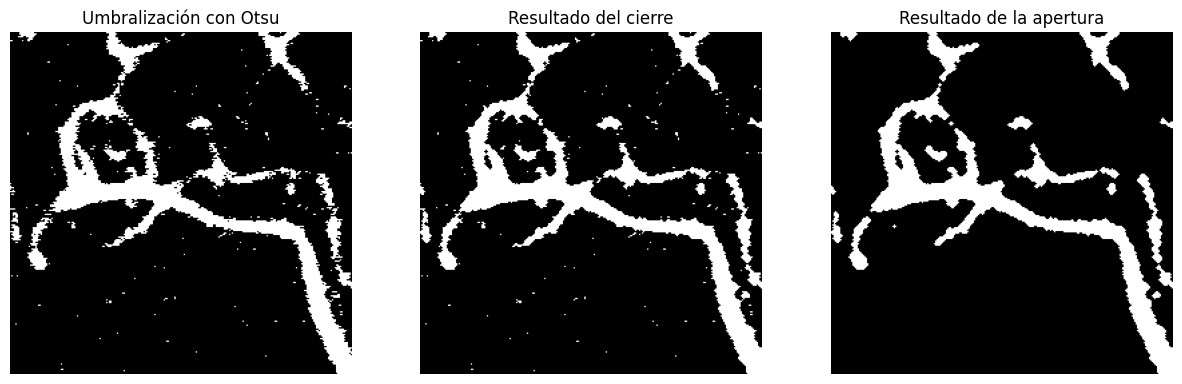

In [127]:
# umbralización con Otsu
thres_value, angio_thresholded = cv2.threshold(angio_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# máscara en cruz de 3x3
cross = np.zeros((3, 3), dtype=np.uint8)
cross[1, :] = 1
cross[:, 1] = 1

# cierre
angio_closed = closing(angio_thresholded, footprint=cross)

# apertura
angio_opened = opening(angio_closed, footprint=cross)

# visualizar resultado de umbralización, cierre y apertura
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(angio_thresholded, cmap='gray', vmin=0, vmax=255)
plt.title('Umbralización con Otsu')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(angio_closed, cmap='gray', vmin=0, vmax=255)
plt.title('Resultado del cierre')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(angio_opened, cmap='gray', vmin=0, vmax=255)
plt.title('Resultado de la apertura')
plt.axis('off')

### 6.8 Efectúe su esqueletización y su adelgazamiento. Compare los resultados de estos dos tratamientos.

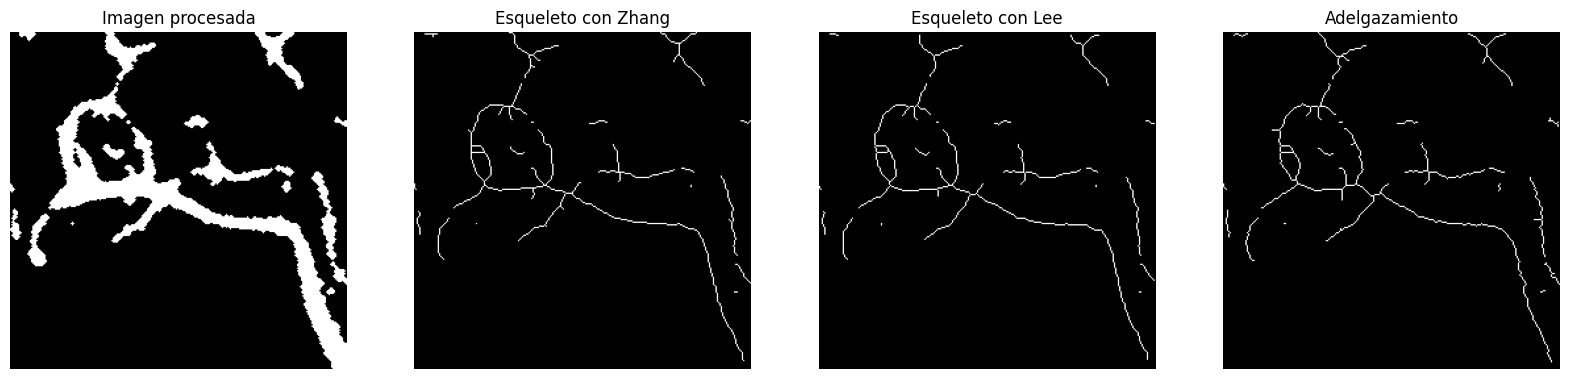

In [128]:
# esqueletización con ambos métodos
esqueleto_zhang = skeletonize(angio_opened, method='zhang')
esqueleto_lee = skeletonize(angio_opened, method='lee')

# adelagazamiento
thin_angio = thin(angio_opened)

# visualizar resultados
plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.imshow(angio_opened, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen procesada')
plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(esqueleto_zhang, cmap='gray')
plt.title('Esqueleto con Zhang')
plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(esqueleto_lee, cmap='gray')
plt.title('Esqueleto con Lee')
plt.axis('off')
plt.subplot(1, 4, 4)
plt.imshow(thin_angio, cmap='gray')
plt.title('Adelgazamiento')
plt.axis('off')
plt.show()

En general, los resultados de los tres métodos son muy similares, aunque con diferencias clave en el acabado. Se percibe que el adelgazamiento es más sensible a las irregularidades del contorno, lo que genera esqueletos con más 'zig-zags' y detalles rugosos. Por el contrario, la esqueletización produce trazos mucho más suaves y uniformes, entregando una estructura más limpia que simplifica la forma original.

### 6.9 Sobreponga la imagen adelgazada a la imagen angio.png (calculando el máximo entre las dos imágenes) para observar la localización de las líneas con respecto a la imagen inicial. Describa de forma cualitativa el resultado obtenido.

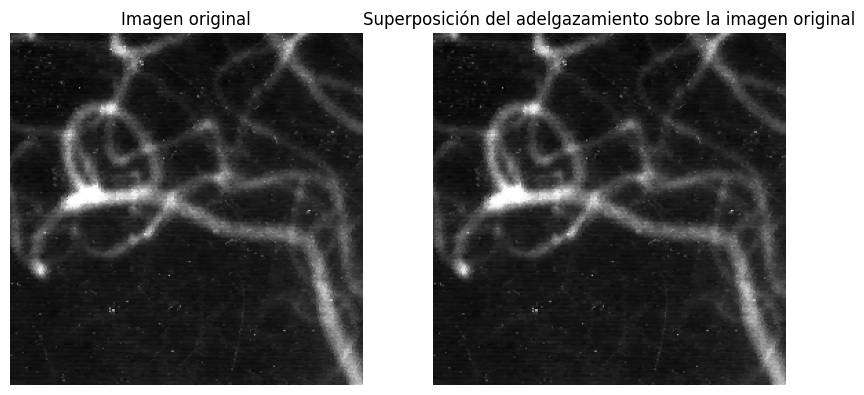

In [129]:
# soreposición del adelgazamiento sobre la imagen original
superposition = np.maximum(thin_angio, angio_image)

# visualizar imagen original y superposición
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(angio_image, cmap='gray')
plt.title('Imagen original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(superposition, cmap='gray')
plt.title('Superposición del adelgazamiento sobre la imagen original')
plt.axis('off')
plt.show()

Al superponer el resultado del adelgazamiento con la imagen original, se logran trazos mucho más definidos y brillantes que en la captura inicial. Lo interesante es que las estructuras con mayor intensidad se conservan intactas, lo que garantiza que no hubo pérdida de información. Este proceso actúa como un realce que destaca las características clave. En conclusión, combinar el adelgazamiento con la imagen base ofrece una visualización más nítida de la estructura, logrando que los detalles esenciales resalten.

## 7. Ejercicio de Síntesis

Abra la imagen objects.png.

Umbralice esta imagen para separar los objetos del fondo (umbral=70).

Realice las operaciones necesarias (incluyendo operaciones morfológicas y de segmentación) sobre esta imagen binaria para conservar únicamente los objetos de espesor de por lo menos 15 píxeles.

Ayuda: una vez detectado un subconjunto de los píxeles de los objetos de interés (objetos de espesor de por lo menos 15 píxeles), puede utilizarlos como puntos semilla para efectuar un crecimiento de regiones.

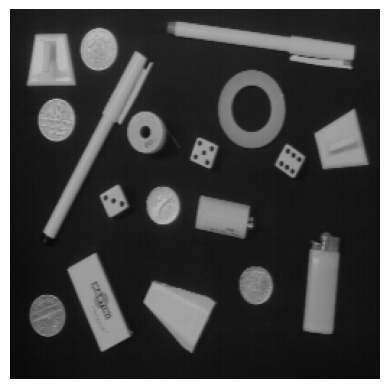

In [131]:
# cargar imagen objects
objects_image = cv2.imread(images_path+'OBJECTS.png', cv2.IMREAD_GRAYSCALE)

# visualizar
plt.imshow(objects_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

En primer lugar, se umbraliza la imagen para obtener una imagen binaria donde los objetos son blancos y el fondo es negro.

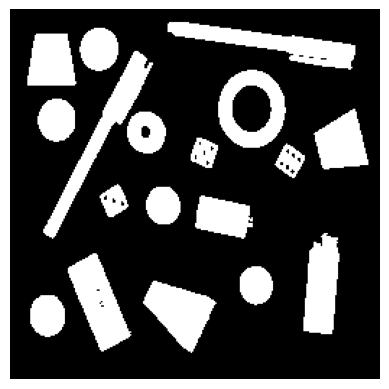

In [132]:
# umbralizar con umbral=70
thres_value, objects_thresholded = cv2.threshold(objects_image, 70, 255, cv2.THRESH_BINARY)

# visualizar
plt.imshow(objects_thresholded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Para obtener los objetos de un grosor de al menos 15 píxeles, podemos aplicar una apertura con un máscara cuadrada de tamaño mayor a 15x15, para que de esta manera, se eliminen todos los objetos con un espesero distinto.

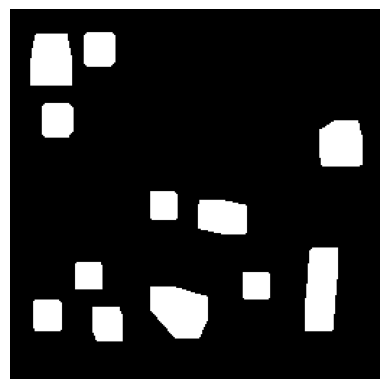

In [152]:
# aplicar erosion y luego dilatación = apertura, con una máscara cuadrada de 17x17
structuring_element_17x17 = footprint_rectangle(shape =(17, 17))
objects_opened = opening(objects_thresholded, footprint=structuring_element_17x17)

# visualizar
plt.imshow(objects_opened, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Con los objetos seleccionados, podemos proceder a calcular los componentes conexos para obtener una semilla correspondiente a cada objeto. Es importante notar que hay un objeto que quedó separado, sin embargo, con el crecimiento de regiones, se seleccionará como uno solo.

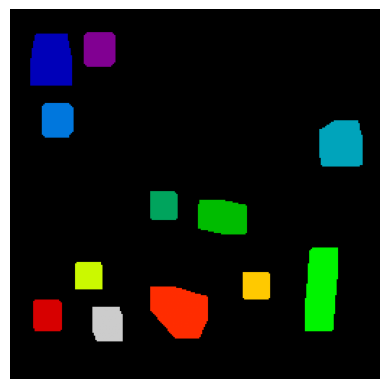

Píxeles semilla para crecimiento de regiones:
[array([16, 53]), array([17, 18]), array([65, 24]), array([ 77, 224]), array([126,  97]), array([132, 131]), array([165, 209]), array([175,  46]), array([182, 161]), array([192,  97]), array([201,  17]), array([206,  57])]


In [155]:
# componentes conexas
connected_components = label(objects_opened, background=0, connectivity=2)

# visualizar componentes conexas
plt.imshow(connected_components, cmap='nipy_spectral')
plt.axis('off')
plt.show()

# seleccionar para cada componente conexa, un píxel que pertenezca a ella como semilla para crecimiento de regiones
seeds = []
for label in np.unique(connected_components):
    if label == 0: # ignorar el fondo
        continue
    mask = connected_components == label
    coords = np.column_stack(np.where(mask))
    seed = coords[0] # tomar el primer píxel que pertenece a la componente conexa como semilla
    seeds.append(seed)

print("Píxeles semilla para crecimiento de regiones:")
print(seeds)

Con las semillas seleccionadas, se procede a obtener sobre la imagen umbralizada los objetos con el procedimiento de crecimiento de regiones.

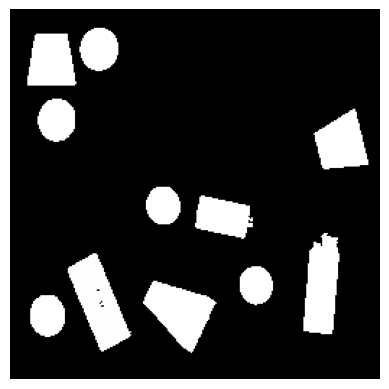

In [158]:
tol = 2 # es un valor bajo porque igual está umbralizada la imagen
imagenes_resultado = []

for seed in seeds:
    seed = tuple(seed) # convertir a tupla para usar como semilla en flood
    mask = flood(objects_thresholded, seed, tolerance=tol)
    imagenes_resultado.append(mask)

# unir las imágenes resultado de cada semilla en una sola imagen
final_result = sum(imagenes_resultado).astype(np.uint8) * 255

# visualizar resultado final del crecimiento de regiones
plt.imshow(final_result, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()